# Group 6: Tasting Feedback Quality Classification

**Text classification with LSTM, BiLSTM and a compact Transformer encoder**  
Synthetic teaching dataset. Session 9: Group Deep Learning Challenge.

<a href="https://colab.research.google.com/github/khairuladib94/dl-food-research/blob/main/session-9/notebooks/06_group6_tasting_feedback_text_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

> **Colab workflow:** Save a copy in Drive, then choose Runtime > Run all. The required teaching dataset downloads automatically; Google Drive is not mounted.



## How to work
1. Run the baseline. 2. Change one main factor in Experiment 1. 3. Change one main factor in Experiment 2. 4. Record evidence for your five-slide presentation.

In [1]:
from pathlib import Path
import os, time, json
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, f1_score, recall_score, precision_score,
                             confusion_matrix, ConfusionMatrixDisplay)

SEED = 42
keras.utils.set_random_seed(SEED)
# Portable workshop data setup: local Jupyter first, Colab fallback.
DATA_FILE = 'group6_tasting_feedback.csv'
LOCAL_DATA_DIR = Path('../data')
if (LOCAL_DATA_DIR / DATA_FILE).exists():
    DATA_DIR = LOCAL_DATA_DIR
    IN_COLAB = False
else:
    from urllib.request import urlretrieve
    try:
        import google.colab  # type: ignore  # noqa: F401
        IN_COLAB = True
    except ImportError:
        IN_COLAB = False
    DATA_DIR = Path('/content/dl-food-research-data') if IN_COLAB else Path.cwd() / '.workshop-data'
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    target = DATA_DIR / DATA_FILE
    if not target.exists():
        url = 'https://raw.githubusercontent.com/khairuladib94/dl-food-research/main' + '/session-9/data/' + DATA_FILE
        print(f'Downloading {DATA_FILE} ...')
        urlretrieve(url, target)
    print(f'Dataset ready: {target}')
FIG_DIR = Path('/content/dl-food-research-figures') if IN_COLAB else Path('../figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('TensorFlow:', tf.__version__, '| Keras:', keras.__version__)


TensorFlow: 2.21.0 | Keras: 3.15.0


## 1. Load and explore the tasting-feedback corpus

,feedback,quality_label,quality_score
0,"Panelist notes: familiar aroma, even texture, ...",acceptable,1
1,"Sensory note: familiar aroma, slightly firm bo...",acceptable,1
2,"Reviewer says: rancid note, watery body, unbal...",poor,0
3,"Sensory note: fermented odor, watery body, bit...",poor,0
4,"Sensory note: familiar aroma, slightly firm bo...",acceptable,1


Shape: (720, 3)


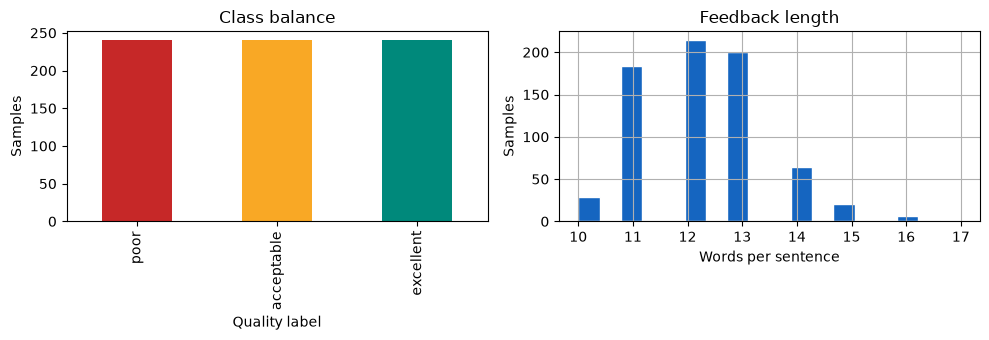


POOR
Reviewer says: rancid note, watery body, unbalanced saltiness, and would not serve.

ACCEPTABLE
Panelist notes: familiar aroma, even texture, moderate seasoning, and average liking.

EXCELLENT
Panelist notes: fresh aroma, creamy texture, balanced flavor, and highly acceptable.


In [2]:
df = pd.read_csv(DATA_DIR / 'group6_tasting_feedback.csv')
display(df.head())
print('Shape:', df.shape)
label_order = ['poor', 'acceptable', 'excellent']
label_to_id = {label: i for i, label in enumerate(label_order)}
df['label_id'] = df['quality_label'].map(label_to_id)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
df['quality_label'].value_counts().reindex(label_order).plot.bar(ax=ax[0], color=['#c62828', '#f9a825', '#00897b'])
ax[0].set(title='Class balance', xlabel='Quality label', ylabel='Samples')
df['feedback'].str.split().str.len().hist(ax=ax[1], bins=18, color='#1565c0', edgecolor='white')
ax[1].set(title='Feedback length', xlabel='Words per sentence', ylabel='Samples')
plt.tight_layout(); plt.savefig(FIG_DIR/'group6_eda.png', dpi=150); plt.show()
for label in label_order:
    print('\n' + label.upper())
    print(df.loc[df['quality_label'].eq(label), 'feedback'].iloc[0])

## 2. Prepare train, validation and untouched test sets

In [3]:
texts = df['feedback'].to_numpy(dtype=str)
y = df['label_id'].values.astype('int64')
X_train, X_test, y_train, y_test = train_test_split(texts, y, test_size=.20, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=.20, stratify=y_train, random_state=SEED)
X_train, X_val, X_test = X_train.astype(str), X_val.astype(str), X_test.astype(str)

max_tokens = 1200
sequence_length = 32
vectorizer = keras.layers.TextVectorization(max_tokens=max_tokens, output_mode='int', output_sequence_length=sequence_length)
vectorizer.adapt(X_train)
X_train_tf = tf.constant(X_train.tolist(), dtype=tf.string)
X_val_tf = tf.constant(X_val.tolist(), dtype=tf.string)
X_test_tf = tf.constant(X_test.tolist(), dtype=tf.string)
print(len(X_train), len(X_val), len(X_test), '| vocabulary size:', len(vectorizer.get_vocabulary()))

460 116 144 | vocabulary size: 121


## 3. Baseline and two controlled experiments

In [4]:
def base_inputs():
    inputs = keras.layers.Input(shape=(1,), dtype=tf.string)
    tokens = vectorizer(inputs)
    x = keras.layers.Embedding(max_tokens, 32)(tokens)
    return inputs, x

def build_lstm(kind='LSTM', units=16, dropout=0.0):
    inputs, x = base_inputs()
    if kind == 'BiLSTM':
        x = keras.layers.Bidirectional(keras.layers.LSTM(units))(x)
    else:
        x = keras.layers.LSTM(units)(x)
    if dropout:
        x = keras.layers.Dropout(dropout)(x)
    outputs = keras.layers.Dense(3, activation='softmax')(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_transformer(embed_dim=32, heads=2, dense_dim=32, dropout=0.10):
    inputs, x = base_inputs()
    attn = keras.layers.MultiHeadAttention(num_heads=heads, key_dim=embed_dim)(x, x)
    x = keras.layers.LayerNormalization()(keras.layers.Add()([x, attn]))
    ff = keras.layers.Dense(dense_dim, activation='relu')(x)
    ff = keras.layers.Dense(embed_dim)(ff)
    x = keras.layers.LayerNormalization()(keras.layers.Add()([x, ff]))
    x = keras.layers.GlobalAveragePooling1D()(x)
    x = keras.layers.Dropout(dropout)(x)
    outputs = keras.layers.Dense(3, activation='softmax')(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def run(name, builder, epochs=6):
    keras.utils.set_random_seed(SEED)
    model = builder()
    hist = model.fit(X_train_tf, y_train, validation_data=(X_val_tf, y_val), epochs=epochs, batch_size=32, verbose=0)
    pred = model.predict(X_test_tf, verbose=0).argmax(1)
    return model, hist, pred, {'run': name, 'accuracy': accuracy_score(y_test, pred), 'macro_F1': f1_score(y_test, pred, average='macro')}

baseline = run('Baseline: LSTM-16', lambda: build_lstm('LSTM', 16), epochs=4)
exp1 = run('Exp 1: BiLSTM-16 + dropout', lambda: build_lstm('BiLSTM', 16, dropout=.15))
exp2 = run('Exp 2: compact Transformer', lambda: build_transformer())
results = pd.DataFrame([baseline[3], exp1[3], exp2[3]])
display(results.round(3))

,run,accuracy,macro_F1
0,Baseline: LSTM-16,0.806,0.783
1,Exp 1: BiLSTM-16 + dropout,1.000,1.000
2,Exp 2: compact Transformer,1.000,1.000


### YOUR TASK
Compare sequence modeling and self-attention for short tasting feedback. Change one main factor at a time, such as BiLSTM units, dropout, vocabulary size or Transformer heads.

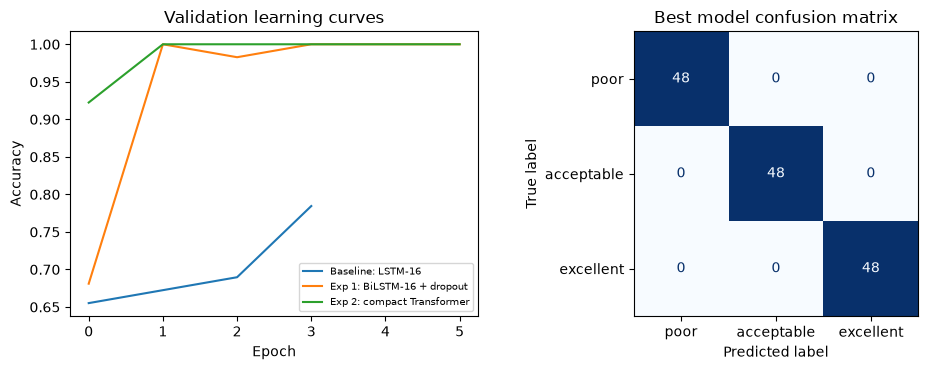

Presentation-ready summary: {'run': 'Exp 1: BiLSTM-16 + dropout', 'accuracy': 1.0, 'macro_F1': 1.0}


In [5]:
best = max([baseline, exp1, exp2], key=lambda r: r[3]['macro_F1'])
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
for r in [baseline, exp1, exp2]:
    ax[0].plot(r[1].history['val_accuracy'], label=r[3]['run'])
ax[0].set(title='Validation learning curves', xlabel='Epoch', ylabel='Accuracy')
ax[0].legend(fontsize=7)
ConfusionMatrixDisplay(confusion_matrix(y_test, best[2]), display_labels=label_order).plot(ax=ax[1], cmap='Blues', colorbar=False)
ax[1].set_title('Best model confusion matrix')
plt.tight_layout(); plt.savefig(FIG_DIR/'group6_results.png', dpi=150); plt.show()
print('Presentation-ready summary:', best[3])